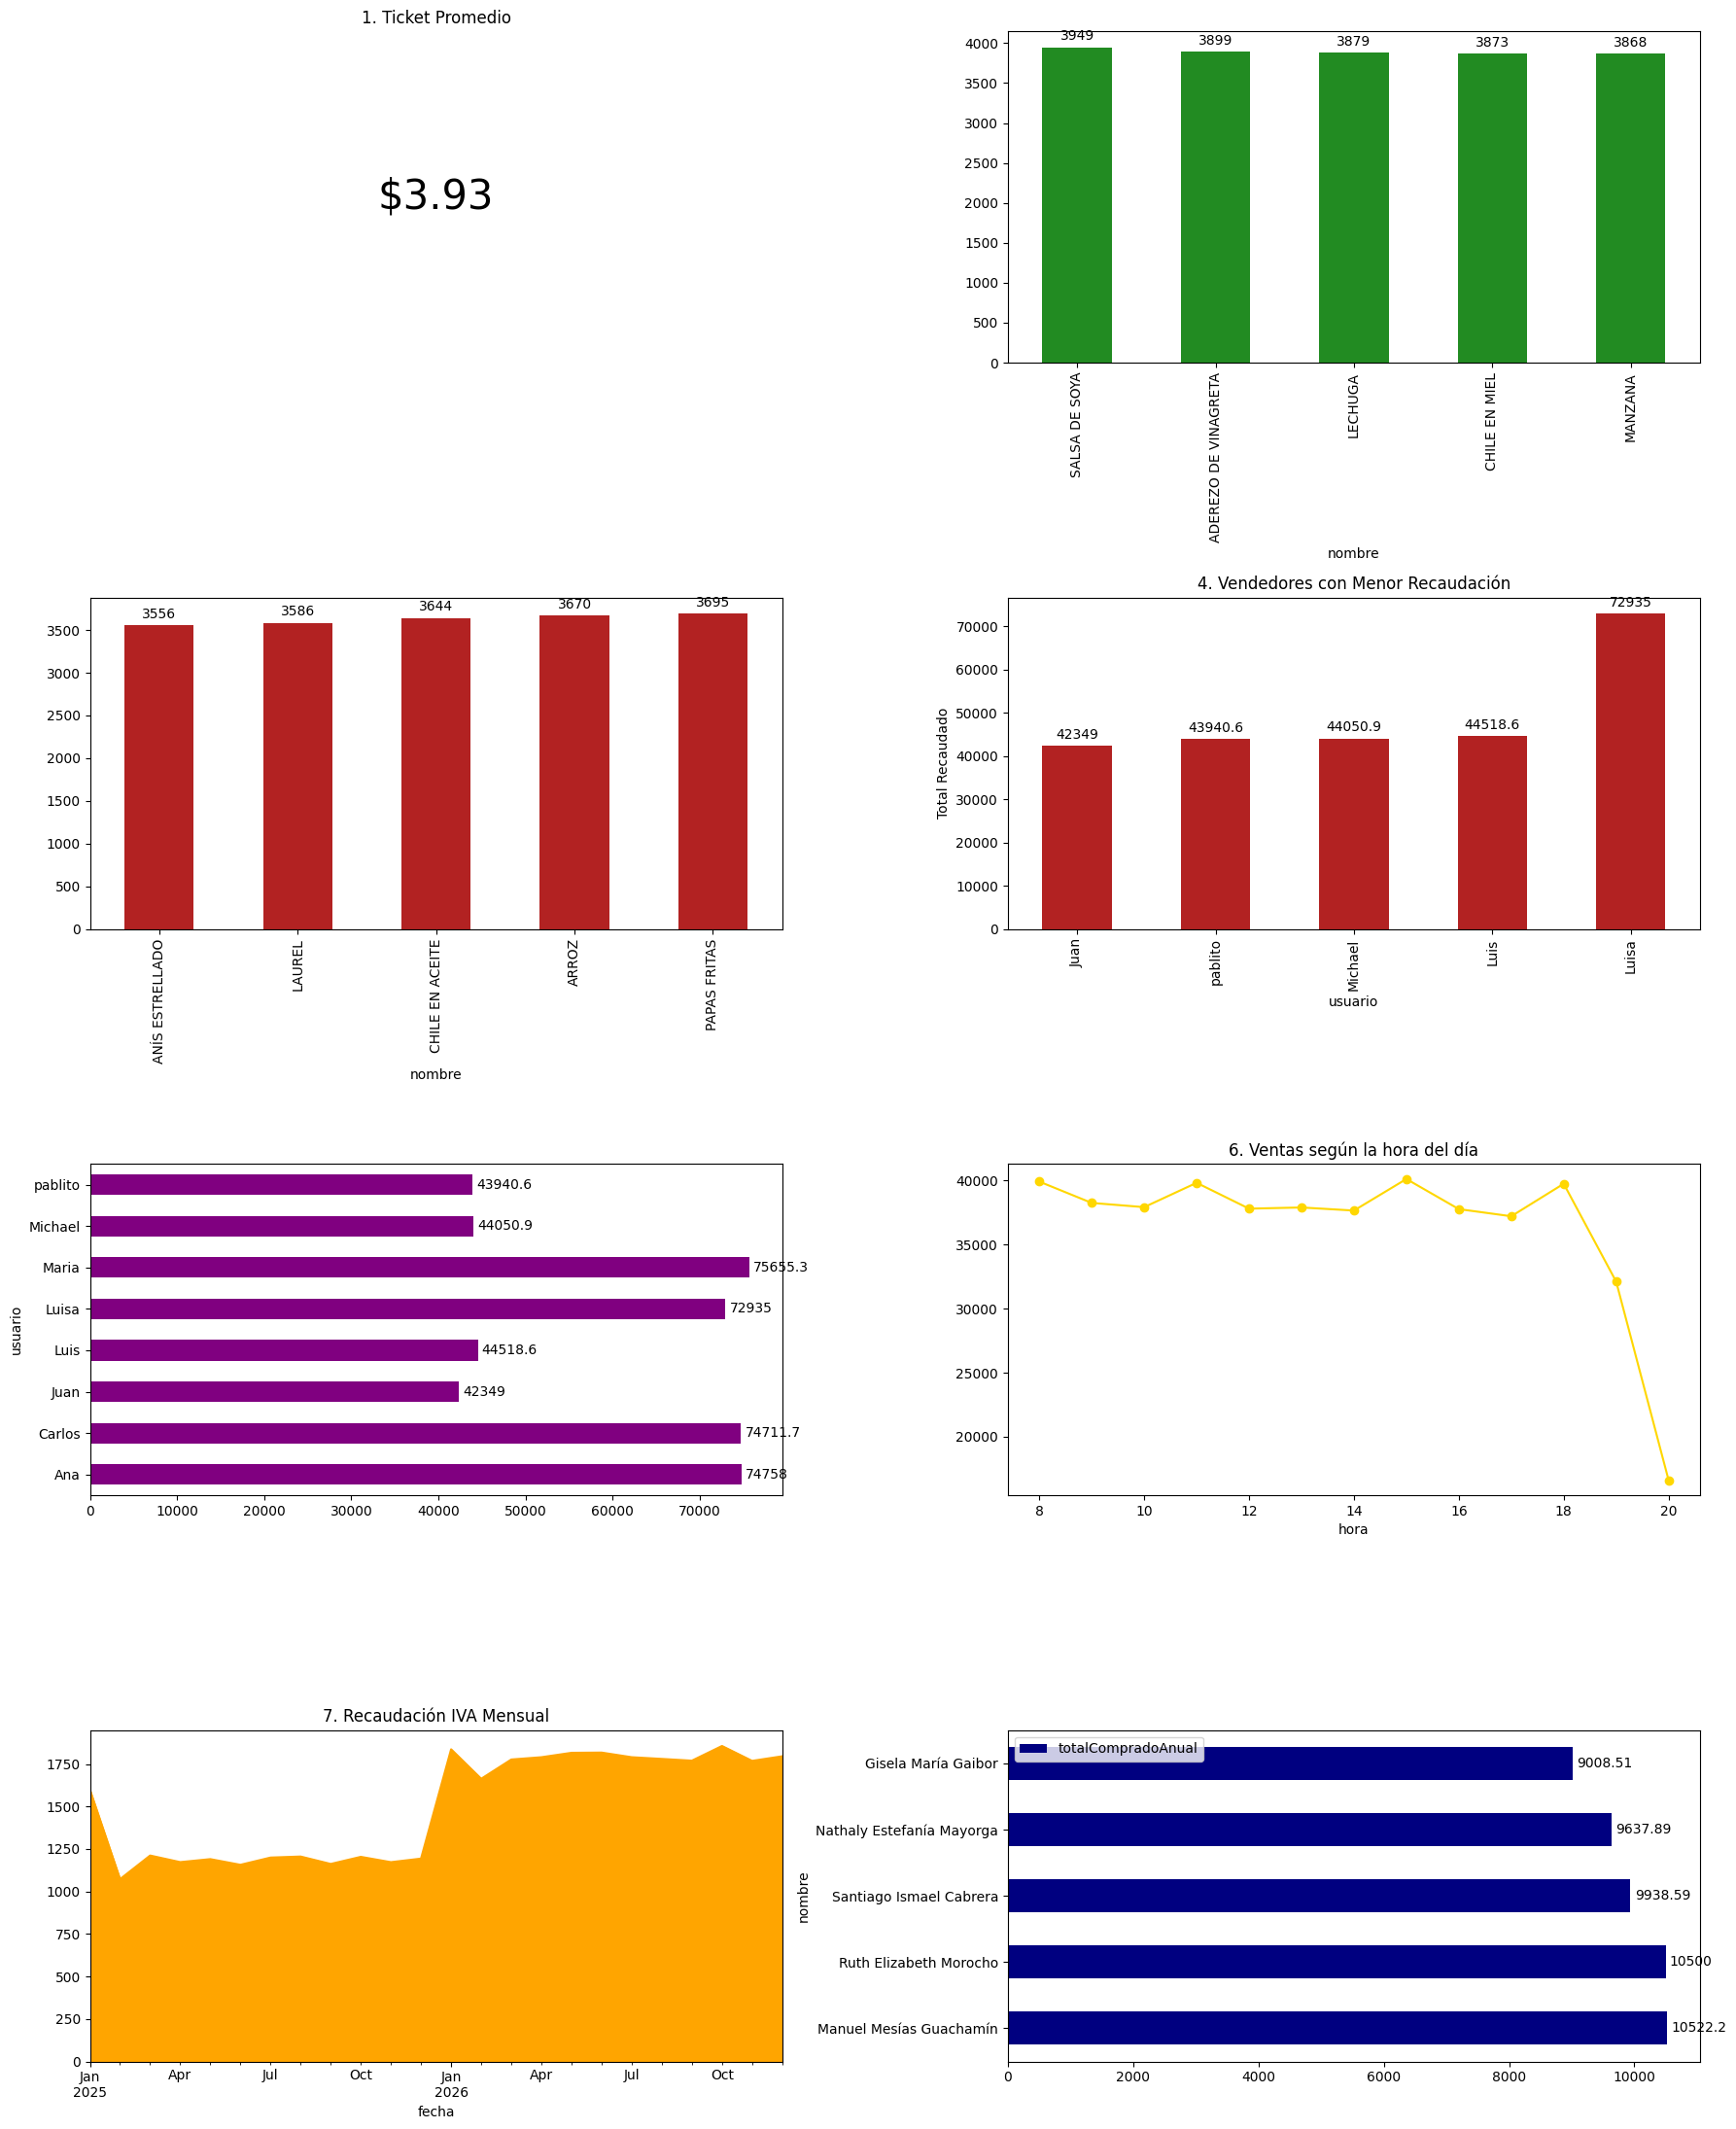

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga de archivos (asegúrate de que las rutas sean correctas)
facturas = pd.read_csv('../puntofast/output/facturas.csv')
clientes = pd.read_csv('../puntofast/output/clientes.csv')

# Conversiones iniciales
facturas['fecha'] = pd.to_datetime(facturas['fecha'])
facturas['hora'] = pd.to_datetime(facturas['hora'], format='%H:%M:%S').dt.hour

# 1. PRE-CÁLCULO necesario para el KPI 4
frecuencia = facturas.groupby('cedulacliente')['facturaID'].nunique()

fig, axes = plt.subplots(4, 2, figsize=(18, 22))

# --- KPI 1: Ticket Promedio ---
ticket_promedio = facturas['totalFactura'].mean()
axes[0, 0].text(0.5, 0.5, f'${ticket_promedio:.2f}', fontsize=30, ha='center', va='center')
axes[0, 0].set_title('1. Ticket Promedio')
axes[0, 0].axis('off') # Ocultar ejes del texto

# KPI 2: Top 5 Productos más vendidos
graf1 = facturas.groupby('nombre')['cantidad'].sum().nlargest(5).plot(kind='bar', ax=axes[0, 1], color='forestgreen')
graf1.bar_label(graf1.containers[0], padding=3)

# KPI 3: Top 5 Productos menos vendidos
graf2 = facturas.groupby('nombre')['cantidad'].sum().nsmallest(5).plot(kind='bar', ax=axes[1, 0], color='firebrick')
graf2.bar_label(graf2.containers[0], padding=3)

# --- KPI 4: Top 5 Vendedores con menor recaudación ---
# Agrupamos por usuario, sumamos sus ventas y tomamos los 5 menores
vendedores_menor_recaudacion = facturas.groupby('usuario')['totalFactura'].sum().nsmallest(5)

# Graficamos
graf3 = vendedores_menor_recaudacion.plot(kind='bar', ax=axes[1, 1], color='firebrick')
graf3.bar_label(graf3.containers[0], padding=3)

# Configuración visual
axes[1, 1].set_title('4. Vendedores con Menor Recaudación')
axes[1, 1].set_ylabel('Total Recaudado')

# KPI 5: Rendimiento por Usuario
graf4 = facturas.groupby('usuario')['totalFactura'].sum().plot(kind='barh', ax=axes[2, 0], color='purple')
graf4.bar_label(graf4.containers[0], padding=3)

# --- KPI 6: Ventas por Hora ---
# Quitamos el bar_label aquí porque un gráfico de líneas no tiene 'containers' de barras
facturas.groupby('hora')['totalFactura'].sum().plot(kind='line', ax=axes[2, 1], color='gold', marker='o')
axes[2, 1].set_title('6. Ventas según la hora del día')

# --- KPI 7: IVA Recaudado Mensual ---
facturas.groupby(facturas['fecha'].dt.to_period('M'))['iva'].sum().plot(kind='area', ax=axes[3, 0], color='orange')
axes[3, 0].set_title('7. Recaudación IVA Mensual')

# KPI 8: Top 5 Clientes por Valor Total
graf5 = clientes.nlargest(5, 'totalCompradoAnual').plot(kind='barh', x='nombre', y='totalCompradoAnual', ax=axes[3, 1], color='navy')
graf5.bar_label(graf5.containers[0], padding=3)

plt.tight_layout()
plt.show()